In [1]:
""" Log
12/27/25 ---- Test for Ns =8, using the ED data wce up to t=1.0 and sce At one point t=0 to construct the interpolation. (Generally speaking, looks good)
"""

' Log\n12/27/25 ---- Test for Ns =8, using the ED data wce up to t=1.0 and sce At one point t=0 to construct the interpolation. (Generally speaking, looks good)\n'

In [2]:
### Plotting the analytic solution G(t, U, iw_n) and G(t(U), U, iw_n)'
import sys
sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt
import utilities as ut
import itertools as it
import pickle
from pydlr import dlr
import cvxpy as cp
import SCE as sce
import WCE as wce
from _bary_rational import AAA_adding0
import greedy_interpolation as greedy

In [3]:
beta = 20.0
Ntau = 401
Ns = 8
Nw = 400
Mat_fre = (2*np.linspace(0, Nw-1, Nw)+1)*np.pi/beta
wn = np.append(-np.flip(Mat_fre),Mat_fre)   # w_n = (2n+1)*pi/beta

In [4]:
### Saving and Loading ED and MBPT data 
t_values_ED = np.around(np.linspace(0,5,51), decimals=1)
U_values_ED = 1+0*t_values_ED
print("ED t is :\n", t_values_ED)

full_sigma = "False"
data_directory_ED = '/global/cfs/cdirs/m1027/Yuan/EDLib_data/1d_hubbard/U1_t_var/'
data_directory_saving = '../ED_data'
ut.Saving_data_ED(Ns, t_values_ED , U_values_ED, Ntau, data_directory_ED, data_directory_saving, full_sigma, beta)
Gij_tau_ED, Gij_iwn_ED, Gk_tau_ED, Gk_iwn_ED  = ut.load_data_training_G_ED(data_directory_saving, Ns, beta)

print(Gij_tau_ED.shape)
print("For Ns=%d, Gij_tau_ED has the dimensionality len(U_values)*Ntau*Ns*Ns=%d*%d*%d*%d" %(Ns, Gij_tau_ED.shape[0], Gij_tau_ED.shape[1], Gij_tau_ED.shape[2], Gij_tau_ED.shape[3]))
print("For Ns=%d, Gij_iwn_ED has the dimensionality len(U_values)*Nw*Ns*Ns=%d*%d*%d*%d" %(Ns, Gij_iwn_ED.shape[0], Gij_iwn_ED.shape[1], Gij_iwn_ED.shape[2], Gij_iwn_ED.shape[3]))
        

ED t is :
 [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7
 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7 2.8 2.9 3.  3.1 3.2 3.3 3.4 3.5
 3.6 3.7 3.8 3.9 4.  4.1 4.2 4.3 4.4 4.5 4.6 4.7 4.8 4.9 5. ]
(51, 401, 8, 8)
For Ns=8, Gij_tau_ED has the dimensionality len(U_values)*Ntau*Ns*Ns=51*401*8*8
For Ns=8, Gij_iwn_ED has the dimensionality len(U_values)*Nw*Ns*Ns=51*800*8*8


In [5]:
t_values_wce = np.linspace(0.5, 5, 501)
t_values_sce = np.linspace(0, 0.1, 51)
Gij_iwn_sce = np.zeros((len(t_values_sce), wn.size, Ns, Ns), dtype ='complex')
Gij_iwn_wce = np.zeros((len(t_values_wce), wn.size, Ns, Ns), dtype ='complex')
Gij_iwn_hf = np.zeros((len(t_values_wce), wn.size, Ns, Ns), dtype ='complex')


Gk_iwn_hf = np.zeros((len(t_values_wce), Ns, wn.size), dtype ='complex')
Gk_iwn_sce = np.zeros((len(t_values_sce), Ns, wn.size), dtype ='complex')
Gk_iwn_wce = np.zeros((len(t_values_wce), Ns, wn.size), dtype ='complex')

for t in range(t_values_sce.size):
    Gij_iwn_sce[t]= sce.Gij_sce_t(2, Ns, 1.0, wn, -t_values_sce[t])
    Gk_iwn_sce[t]= wce.Gij_to_Gk(Gij_iwn_sce[t])
for t in range(t_values_wce.size):
    Gij_iwn_hf[t], _ = wce.HF_G0(-t_values_wce[t], Ns, wn)
    Gij_iwn_wce[t]= wce.Gij_wce_U(2, Ns, 1.0, wn, beta, -t_values_wce[t])

    Gk_iwn_hf[t]= wce.Gij_to_Gk(Gij_iwn_hf[t])
    Gk_iwn_wce[t]= wce.Gij_to_Gk(Gij_iwn_wce[t])

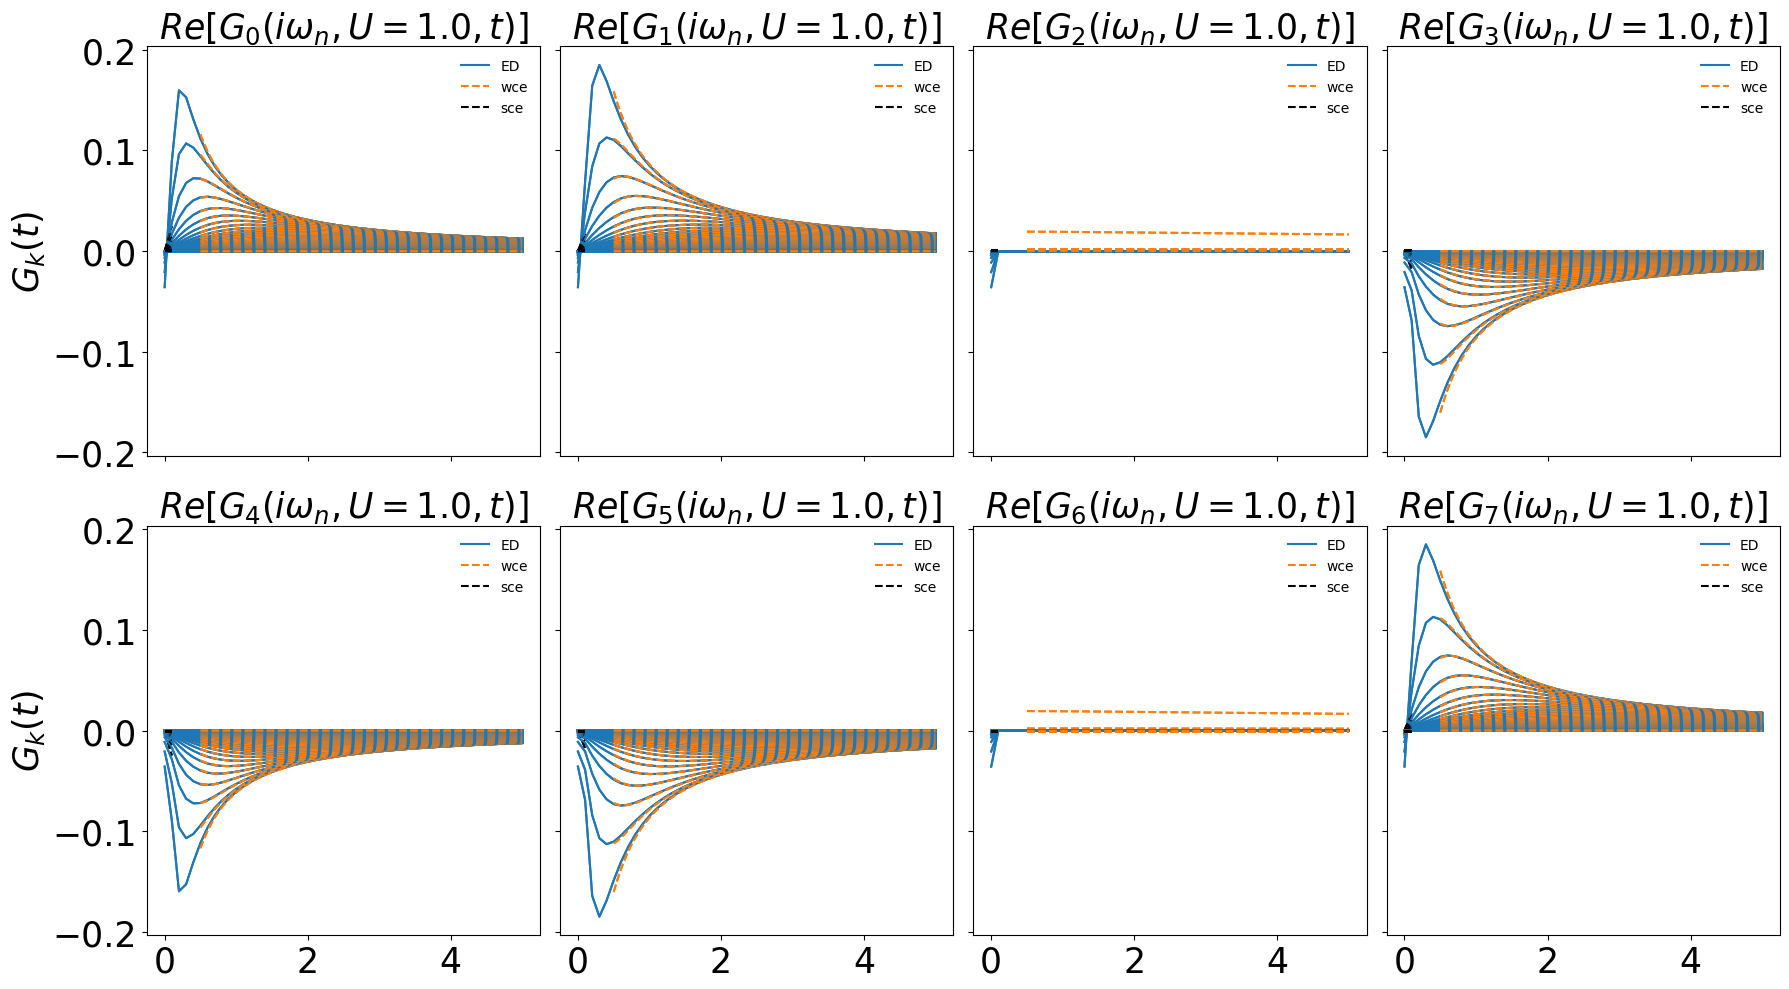

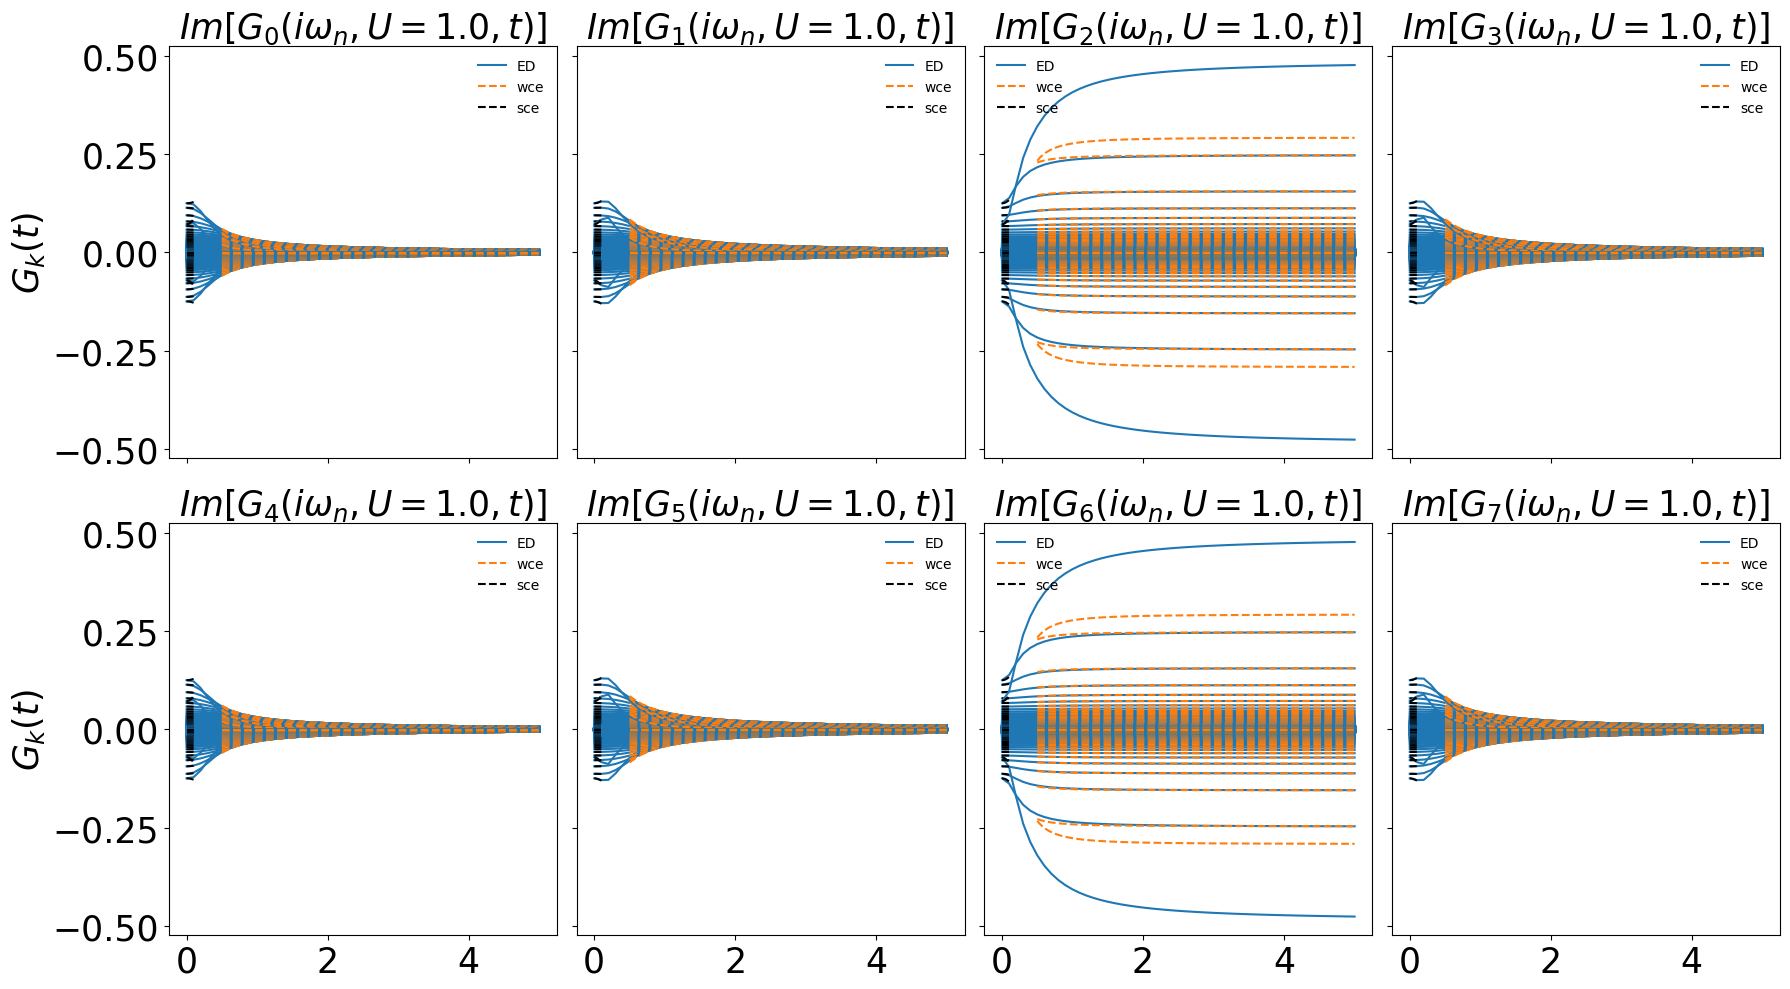

In [6]:
#### Plotting Gk_iwn 

fig, axes = plt.subplots(2, int(Ns/2), figsize=(18, 10),sharex=True, sharey=True)
k = 0
for i in range(2):
    for j in range(int(Ns/2)):
        ax = axes[i, j]
        for n in range(wn.size):
            ax.plot(t_values_ED, Gk_iwn_ED[:, k, n].real, 'C0')
            ax.plot(t_values_wce, Gk_iwn_wce[:, k, n].real, 'C1--')
            ax.plot(t_values_sce, Gk_iwn_sce[:, k, n].real, 'k--')

        ax.plot(t_values_ED, Gk_iwn_ED[:, k, n].real, 'C0', label = 'ED')
        ax.plot(t_values_wce, Gk_iwn_wce[:, k, n].real, 'C1--', label = 'wce')
        ax.plot(t_values_sce, Gk_iwn_sce[:, k, n].real, 'k--', label = 'sce')
        ax.set_title(r'$Re[G_{%d}(i\omega_n,U=%.1f, t)]$'%(k,U_values_ED[0]), fontsize=25)
        ax.tick_params(labelsize=25)
        ax.legend(frameon = False)
        k = k+1

        if i == Ns - 1:
            ax.set_xlabel("t", fontsize=25)
            ax.set_xlim([0,2])
            ax.set_ylim([-0.5,1])
        if j == 0:
            ax.set_ylabel(r"$G_k(t)$", fontsize=25)

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(2, int(Ns/2), figsize=(18, 10),sharex=True, sharey=True)
k = 0
for i in range(2):
    for j in range(int(Ns/2)):
        ax = axes[i, j]
        for n in range(wn.size):
            ax.plot(t_values_ED, Gk_iwn_ED[:, k, n].imag, 'C0')
            ax.plot(t_values_wce, Gk_iwn_wce[:, k, n].imag, 'C1--')
            ax.plot(t_values_sce, Gk_iwn_sce[:, k, n].imag, 'k--')
            
        ax.plot(t_values_ED, Gk_iwn_ED[:, k, n].imag, 'C0', label = 'ED')
        ax.plot(t_values_wce, Gk_iwn_wce[:, k, n].imag, 'C1--', label = 'wce')
        ax.plot(t_values_sce, Gk_iwn_sce[:, k, n].imag, 'k--', label = 'sce')
        ax.set_title(r'$Im[G_{%d}(i\omega_n,U=%.1f, t)]$'%(k,U_values_ED[0]), fontsize=25)
        ax.tick_params(labelsize=25)
        ax.legend(frameon = False)
        k = k+1

        if i == Ns - 1:
            ax.set_xlabel("t", fontsize=25)
            ax.set_xlim([0,2])
            ax.set_ylim([-0.5,1])
        if j == 0:
            ax.set_ylabel(r"$G_k(t)$", fontsize=25)

plt.tight_layout()
plt.show()




In [7]:
# ### Constructing the sce+ wce interpolation data 
tl = 0.5
idl = np.argmin(np.abs(t_values_wce - tl))

wce_t = t_values_wce[idl:]
wce_G = Gk_iwn_wce[idl:]
print("WCE data length=", wce_G.shape)

tr = 0.05
idr = np.argmin(np.abs(t_values_sce - tr))

sce_t = t_values_sce[:idr ]
sce_G = Gk_iwn_sce[:idr]
print("SCE data length=", sce_G.shape)


t_app = np.concatenate([wce_t , sce_t ], axis=0)
G_app = np.concatenate([wce_G , sce_G ], axis=0)

# ### Constructing the ED interpolation data 
# tl = 1.0
# idl = np.argmin(np.abs(t_values_ED - tl))

# wce_t = t_values_ED[idl:]
# wce_G = Gij_iwn_ED[idl:, :, :, :]
# print("WCE data length=", wce_t.size)

# tr = 0.05
# idr = np.argmin(np.abs(t_values_ED - tr))

# sce_t = t_values_ED[:idr+1 ]
# sce_G = Gij_iwn_ED[:idr+1, :, :, :]
# print("SCE data length=", sce_t.size)


WCE data length= (501, 8, 800)
SCE data length= (25, 8, 800)


In [9]:
### AAA interpolation 
err_bar1 = 1e-2
t_interp = np.linspace(0,5,501)

Nw_interp =  200
half = Nw_interp
mid = wn.size // 2 
print(wn.size, )
wn_ids = np.arange(mid-half, mid+half+1)

Gk_iwn_interp_greedy = np.zeros((t_interp.size, Ns, wn.size), dtype = complex)


# for n in range(wn.size):
for n in wn_ids:
    print("n=", n, "w_n=", wn[n])
    for k in range(Ns):
        # Gk_iwn_interp_greedy[:, k, n] = greedy.Gk_interp(sce_G[:, k, n], sce_t, wce_G[:, k, n], wce_t, t_interp,  err=err_bar1, max_terms= 40)
        r = AAA_adding0(t_app, G_app[:, k, n],  rtol=err_bar1, max_terms= 40)
        Gk_iwn_interp_greedy[:, k, n] = r(t_interp)

800
n= 200 w_n= -62.67477343911637
n= 201 w_n= -62.36061417375739
n= 202 w_n= -62.04645490839842
n= 203 w_n= -61.732295643039436
n= 204 w_n= -61.418136377680455
n= 205 w_n= -61.10397711232148
n= 206 w_n= -60.7898178469625
n= 207 w_n= -60.475658581603525
n= 208 w_n= -60.16149931624453
n= 209 w_n= -59.847340050885556
n= 210 w_n= -59.533180785526575
n= 211 w_n= -59.2190215201676
n= 212 w_n= -58.90486225480862
n= 213 w_n= -58.59070298944964
n= 214 w_n= -58.276543724090665
n= 215 w_n= -57.962384458731684
n= 216 w_n= -57.64822519337271
n= 217 w_n= -57.33406592801373
n= 218 w_n= -57.01990666265475
n= 219 w_n= -56.70574739729576
n= 220 w_n= -56.391588131936786
n= 221 w_n= -56.077428866577804
n= 222 w_n= -55.76326960121882
n= 223 w_n= -55.44911033585985
n= 224 w_n= -55.13495107050087
n= 225 w_n= -54.820791805141894
n= 226 w_n= -54.50663253978291
n= 227 w_n= -54.19247327442393
n= 228 w_n= -53.87831400906496
n= 229 w_n= -53.56415474370597
n= 230 w_n= -53.24999547834699
n= 231 w_n= -52.93583621298

The predicted wn frequencies are [ 2.35619449  2.04203522  1.72787596  1.41371669  1.09955743  0.78539816
  0.4712389   0.15707963 -0.15707963 -0.4712389  -0.78539816 -1.09955743
 -1.41371669 -1.72787596]


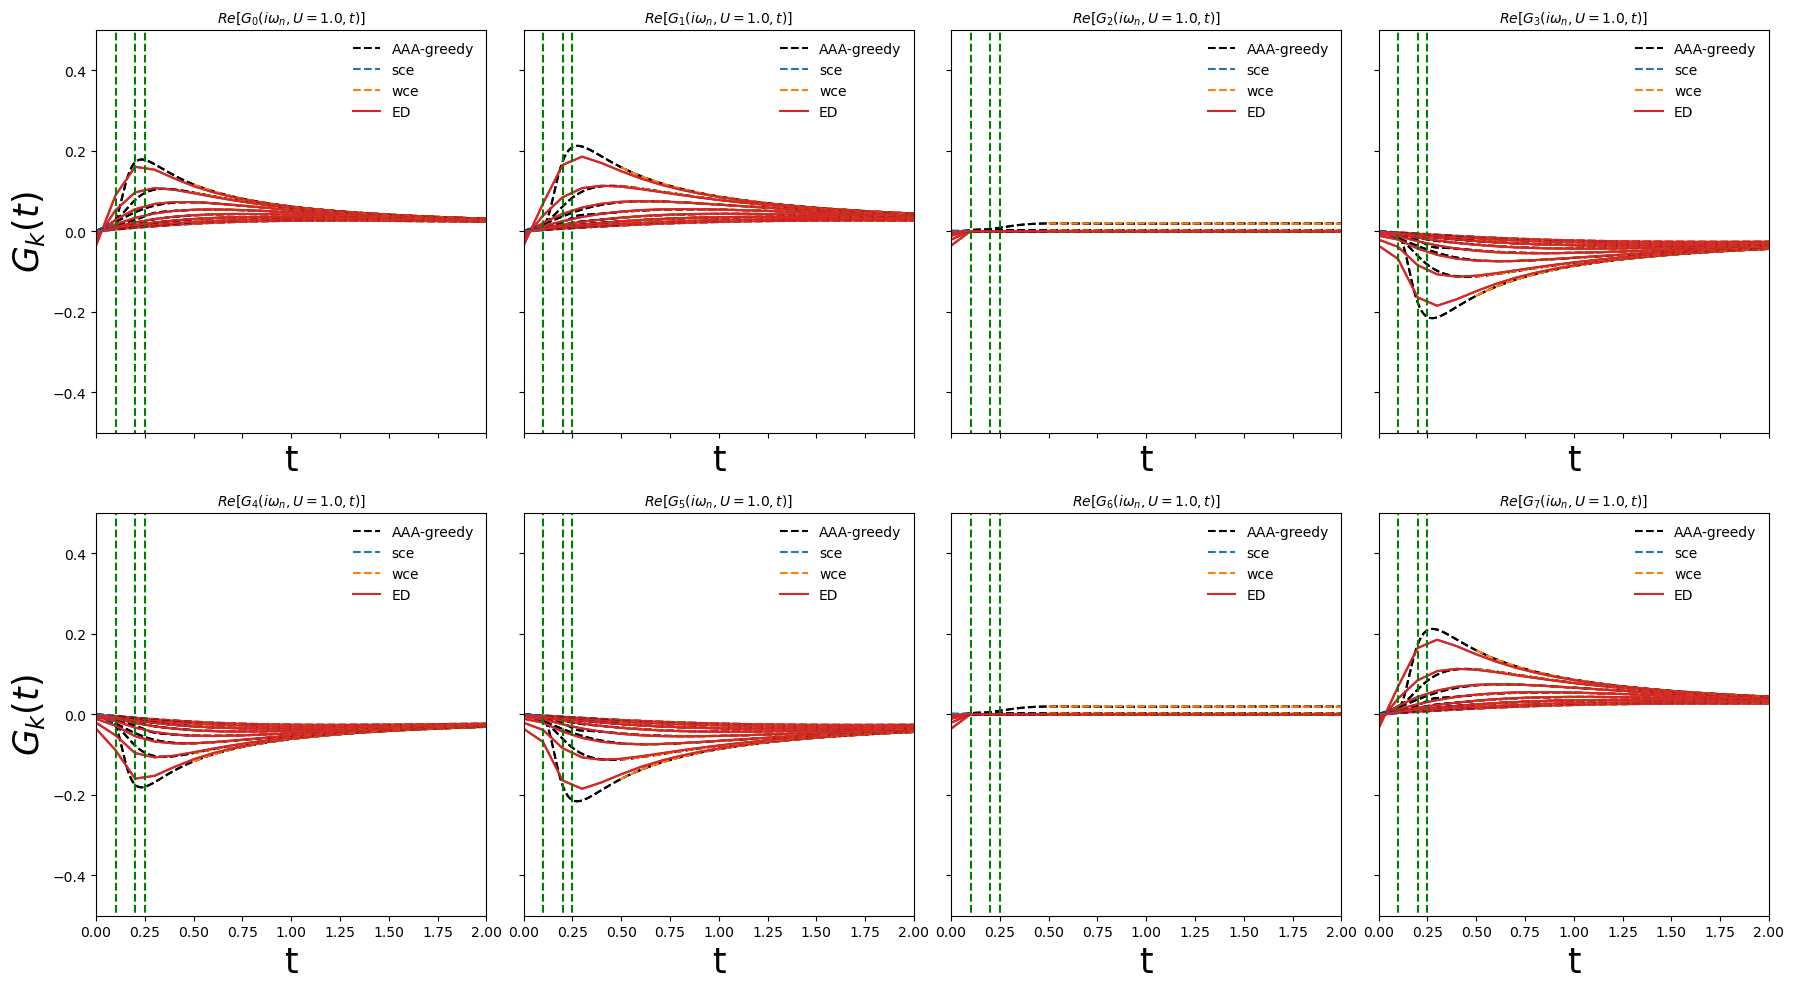

In [10]:
wn_id = [Nw+7, Nw+6, Nw+5, Nw+4, Nw+3, Nw+2, Nw+1, Nw, Nw-1, Nw-2, Nw-3, Nw-4, Nw-5, Nw-6]
Ns_plot = 4
print("The predicted wn frequencies are", wn[wn_id])
fig, axes = plt.subplots(2, int(Ns/2), figsize=(18,10),sharex=True, sharey=True)

k = 0 
for i in range(2):
    for j in range(int(Ns/2)):
        ax = axes[i, j]
        for n in wn_id:
        # for k in range(wn.size):
            # ax.plot(t_interp, Gij_iwn_interp[:, k, i ,j ].real, 'C0')
            ax.plot(t_interp, Gk_iwn_interp_greedy[:, k, n ].real, 'k--')
            ax.plot(t_values_sce, Gk_iwn_sce[:, k, n  ].real, 'C0--')
            ax.plot(t_values_wce, Gk_iwn_wce[:, k,n  ].real, 'C1--')
            # ax.plot(t_values_wce, Gij_iwn_hf[:, k, i ,j ].real, 'C2--')
            ax.plot(t_values_ED, Gk_iwn_ED[:, k,n  ].real, 'C3')
   
        # ax.plot(t_interp, Gij_iwn_interp[:, k, i ,j ].real, 'C0', label= 'AAA')
        ax.plot(t_interp, Gk_iwn_interp_greedy[:, k, n  ].real, 'k--', label= 'AAA-greedy')
        ax.plot(1/4+0*t_interp, np.linspace(-5,5,t_interp.size), 'g--')
        ax.plot(1/5+0*t_interp, np.linspace(-5,5,t_interp.size), 'g--')
        ax.plot(1/10+0*t_interp, np.linspace(-5,5,t_interp.size), 'g--')
        
        ax.plot(t_values_sce, Gk_iwn_sce[:, k, n  ].real, 'C0--', label= 'sce')
        ax.plot(t_values_wce, Gk_iwn_wce[:, k, n  ].real, 'C1--', label= 'wce')
        # ax.plot(t_values_wce, Gij_iwn_hf[:, k, i ,j ].real, 'C2--', label= 'HF')
        ax.plot(t_values_ED, Gk_iwn_ED[:, k, n  ].real, 'C3', label='ED')
        ax.set_title(r'$Re[G_{%d}(i\omega_n,U=%.1f, t)]$'%(k,1.0), fontsize=10)
        ax.tick_params(labelsize=10)
        ax.legend(frameon = False)

        k = k+1

        ax.set_xlabel("t", fontsize=25)
        ax.set_xlim([0,2])
        ax.set_ylim([-0.5,0.5])
        if j == 0:
            ax.set_ylabel(r"$G_k(t)$", fontsize=25)

plt.tight_layout()
plt.show()

The predicted wn frequencies are [ 2.35619449  2.04203522  1.72787596  1.41371669  1.09955743  0.78539816
  0.4712389   0.15707963 -0.15707963 -0.4712389  -0.78539816 -1.09955743
 -1.41371669 -1.72787596]


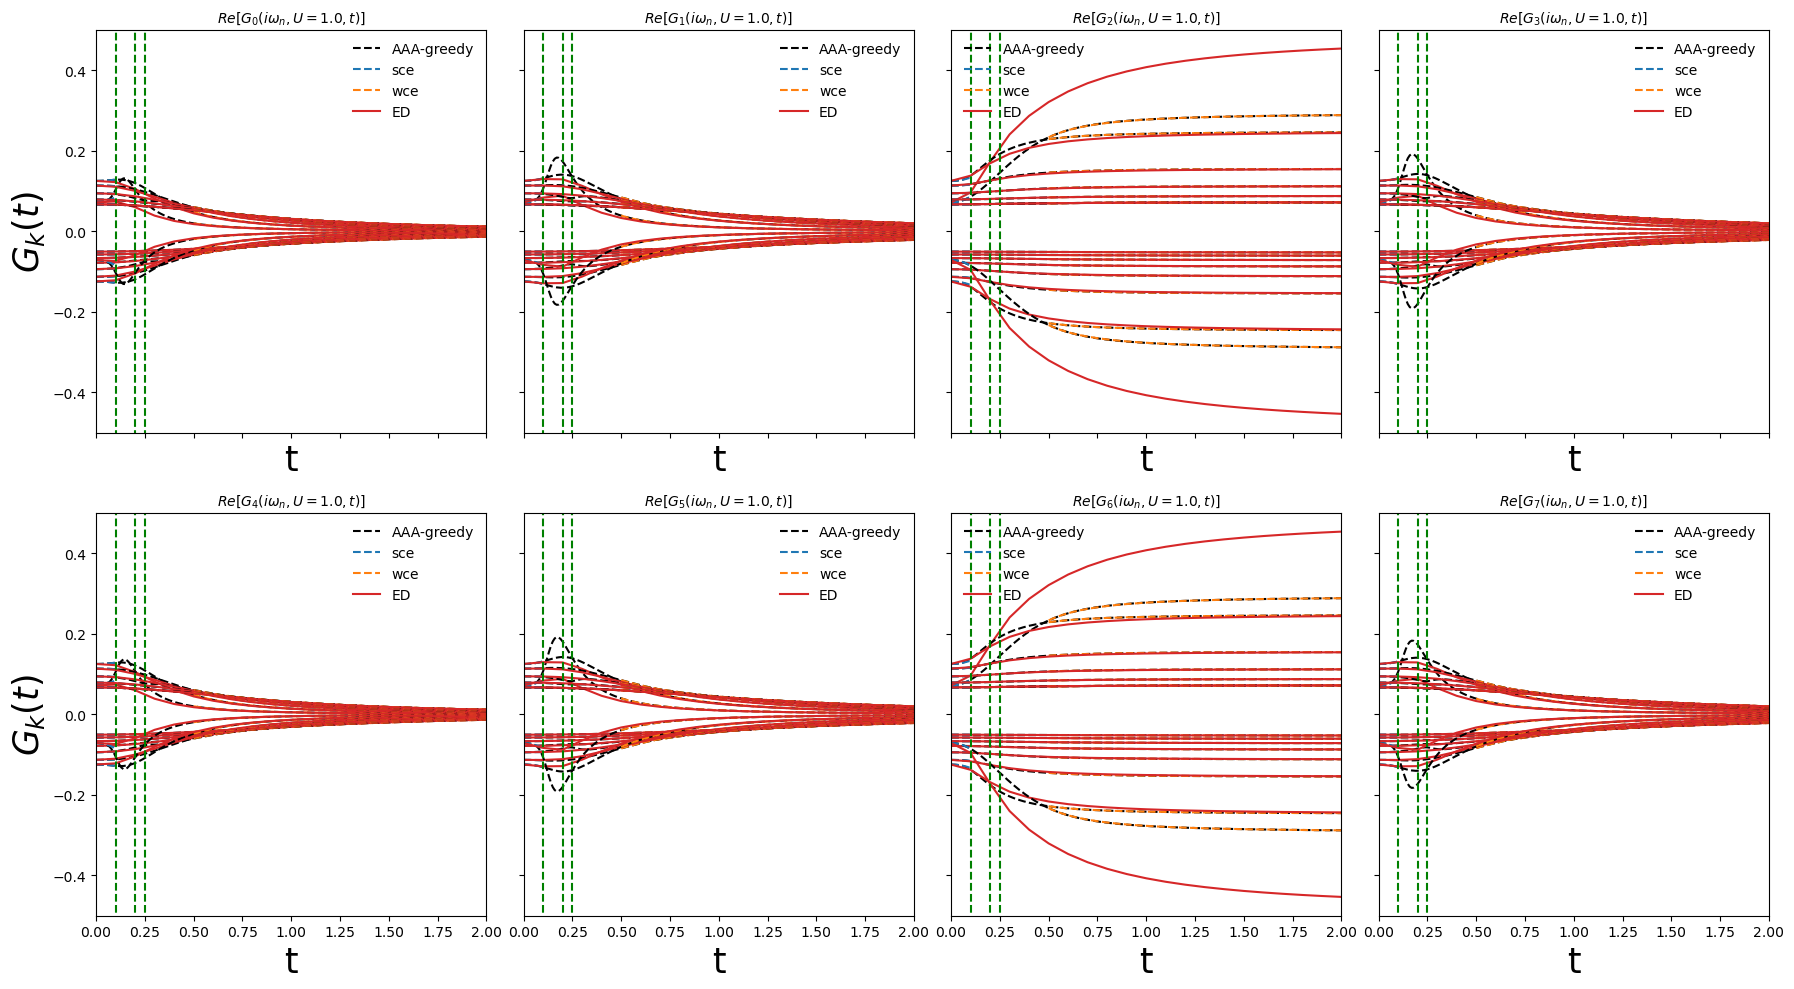

In [11]:
wn_id = [Nw+7, Nw+6, Nw+5, Nw+4, Nw+3, Nw+2, Nw+1, Nw, Nw-1, Nw-2, Nw-3, Nw-4, Nw-5, Nw-6]
Ns_plot = 4
print("The predicted wn frequencies are", wn[wn_id])
fig, axes = plt.subplots(2, int(Ns/2), figsize=(18,10),sharex=True, sharey=True)

k = 0 
for i in range(2):
    for j in range(int(Ns/2)):
        ax = axes[i, j]
        for n in wn_id:
        # for k in range(wn.size):
            ax.plot(t_interp, Gk_iwn_interp_greedy[:, k, n ].imag, 'k--')
            ax.plot(t_values_sce, Gk_iwn_sce[:, k, n  ].imag, 'C0--')
            ax.plot(t_values_wce, Gk_iwn_wce[:, k,n  ].imag, 'C1--')
            ax.plot(t_values_ED, Gk_iwn_ED[:, k,n  ].imag, 'C3')
   
        ax.plot(t_interp, Gk_iwn_interp_greedy[:, k, n  ].imag, 'k--', label= 'AAA-greedy')
        ax.plot(1/4+0*t_interp, np.linspace(-5,5,t_interp.size), 'g--')
        ax.plot(1/5+0*t_interp, np.linspace(-5,5,t_interp.size), 'g--')
        ax.plot(1/10+0*t_interp, np.linspace(-5,5,t_interp.size), 'g--')
        
        ax.plot(t_values_sce, Gk_iwn_sce[:, k, n  ].imag, 'C0--', label= 'sce')
        ax.plot(t_values_wce, Gk_iwn_wce[:, k, n  ].imag, 'C1--', label= 'wce')
        ax.plot(t_values_ED, Gk_iwn_ED[:, k, n  ].imag, 'C3', label='ED')
        ax.set_title(r'$Re[G_{%d}(i\omega_n,U=%.1f, t)]$'%(k,1.0), fontsize=10)
        ax.tick_params(labelsize=10)
        ax.legend(frameon = False)

        k = k+1

        ax.set_xlabel("t", fontsize=25)
        ax.set_xlim([0,2])
        ax.set_ylim([-0.5,0.5])
        if j == 0:
            ax.set_ylabel(r"$G_k(t)$", fontsize=25)

plt.tight_layout()
plt.show()

0.2
0.2


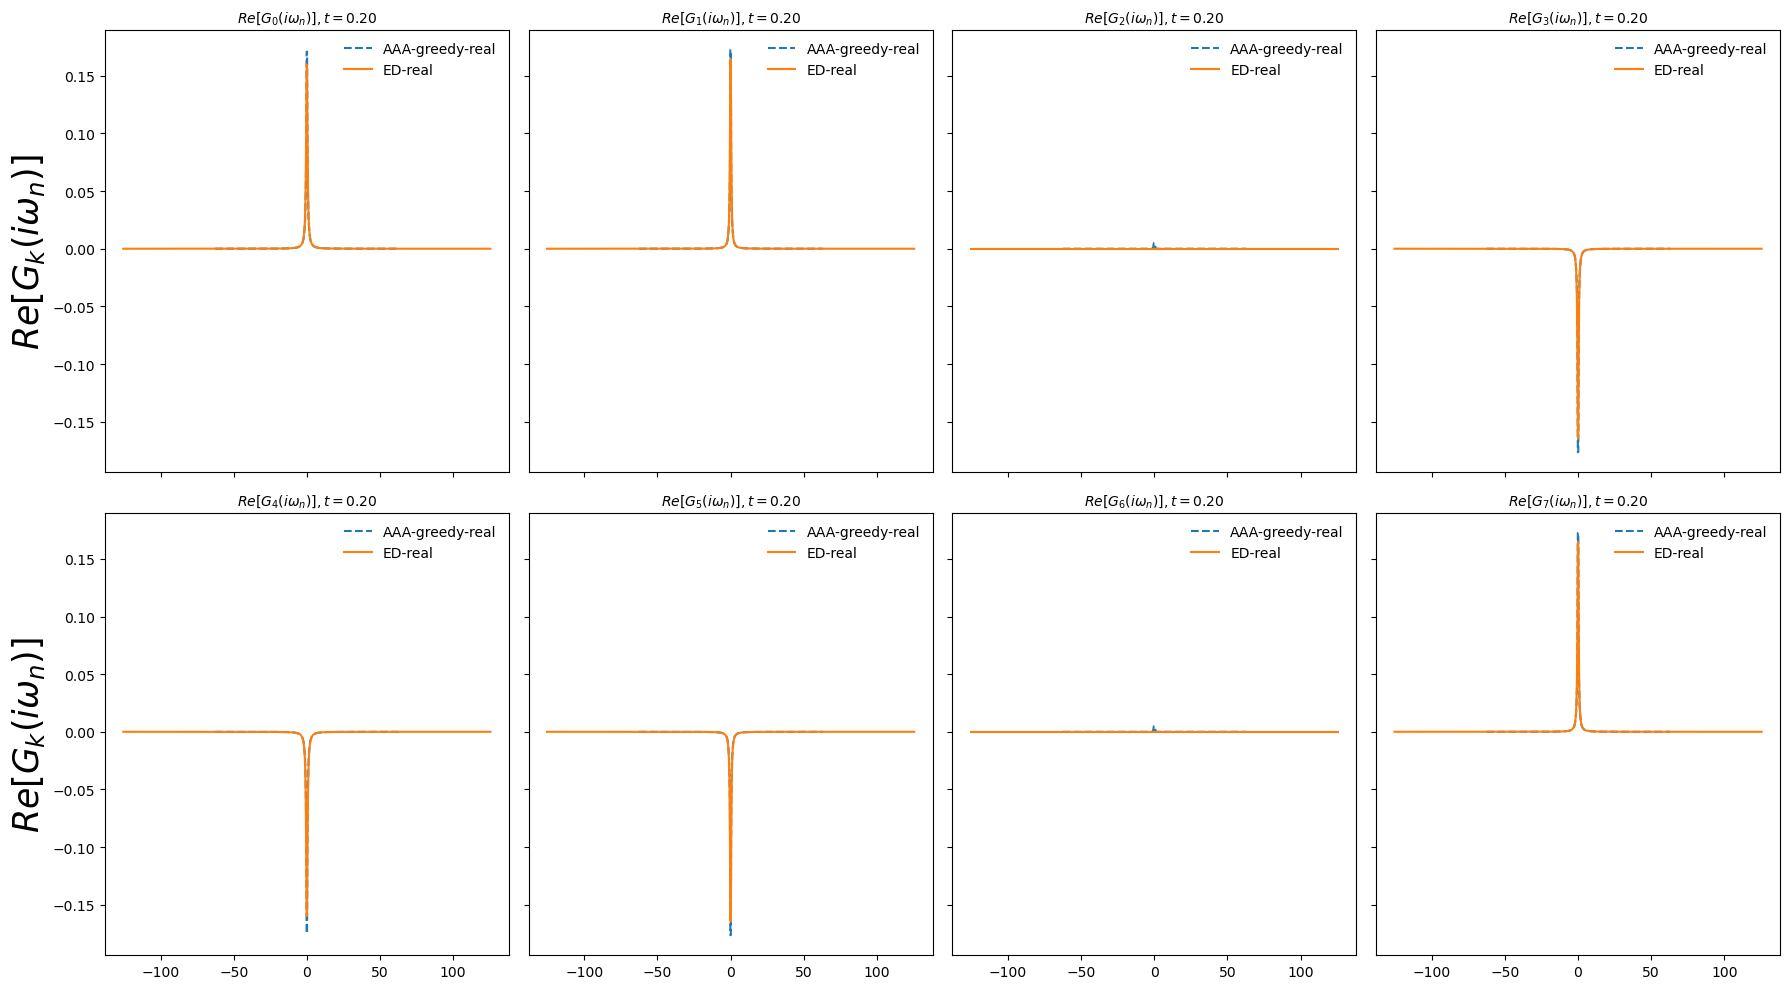

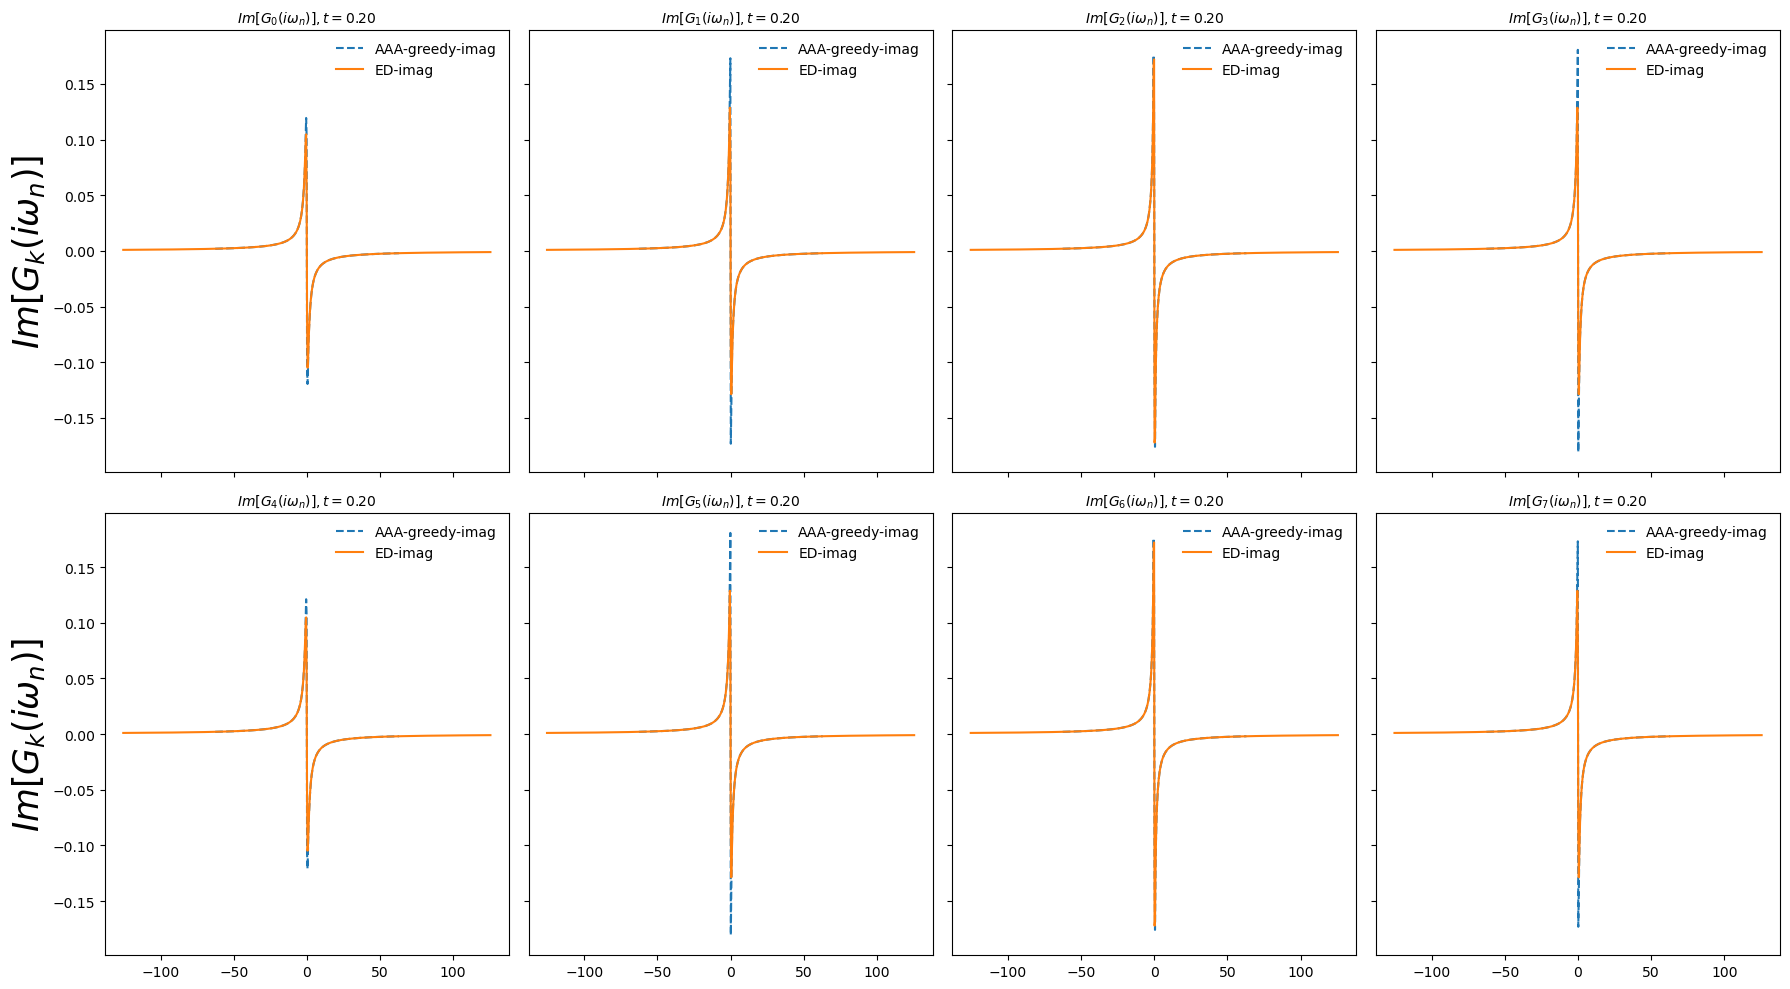

In [12]:
# print("This runs")
# raise SystemExit
# print("This will NOT run")

t_test = 0.2
id_ed = np.argmin(np.abs(t_test - t_values_ED))
id_aaa = np.argmin(np.abs(t_test - t_interp))
print(t_values_ED[id_ed])
print(t_interp[id_aaa])


mask = (np.arange(wn.size)  >= mid - half) & (np.arange(wn.size) <= mid + half)
wn_interp = wn[mask]
Gk_iwn_interp = Gk_iwn_interp_greedy[:,:, mask]
# Gk_iwn_interp[:, 2,:] = 1j*Gk_iwn_interp[:, 2,:].imag
# Gk_iwn_interp[:, 6,:] = 1j*Gk_iwn_interp[:, 6,:].imag

Ns_plot = 4
fig, axes = plt.subplots(2, int(Ns/2), figsize=(18, 10),sharex=True, sharey=True)
k = 0
for i in range(2):
    for j in range(int(Ns/2)):
        ax = axes[i, j]
        ax.plot(wn_interp, Gk_iwn_interp[id_aaa, k, : ].real, 'C0--', label= 'AAA-greedy-real')
        ax.plot(wn, Gk_iwn_ED[id_ed, k, : ].real, 'C1', label= 'ED-real')
        ax.set_title(r'$Re[G_{%d}(i\omega_n)], t=%.2f$'%(k, t_values_ED[id_ed]), fontsize=10)
        ax.tick_params(labelsize=10)
        ax.legend(frameon = False)

        k = k+1
        if i == Ns_plot - 1:
            ax.set_xlabel(r"$\omega_n$", fontsize=25)
            ax.set_xlim([-20,20])
            ax.set_ylim([-2,2])
        if j == 0:
            ax.set_ylabel(r"$Re[G_k(i\omega_n)]$", fontsize=25)

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(2, int(Ns/2), figsize=(18, 10),sharex=True, sharey=True)
k = 0
for i in range(2):
    for j in range(int(Ns/2)):
        ax = axes[i, j]
        ax.plot(wn_interp, Gk_iwn_interp[id_aaa, k, : ].imag, 'C0--', label= 'AAA-greedy-imag')
        ax.plot(wn, Gk_iwn_ED[id_ed, k, : ].imag, 'C1', label= 'ED-imag')
        ax.set_title(r'$Im[G_{%d}(i\omega_n)], t=%.2f$'%(k, t_values_ED[id_ed]), fontsize=10)
        ax.tick_params(labelsize=10)
        ax.legend(frameon = False)

        k = k+1
        if i == Ns_plot - 1:
            ax.set_xlabel(r"$\omega_n$", fontsize=25)
            ax.set_xlim([-20,20])
            ax.set_ylim([-2,2])
        if j == 0:
            ax.set_ylabel(r"$Im[G_k(i\omega_n)]$", fontsize=25)

plt.tight_layout()
plt.show()


In [13]:
### Using pydlr to get approximated Green's function G_ij(iwn) and G_ij(tau)
tau = np.linspace(0,beta,401)
Gij_iwn_interp = wce.Gk_to_Gij(Gk_iwn_interp[id_aaa])
Gij_tau_interp = wce.Gij_iwn_to_Gij_tau(Gij_iwn_interp, wn_interp, tau, beta)

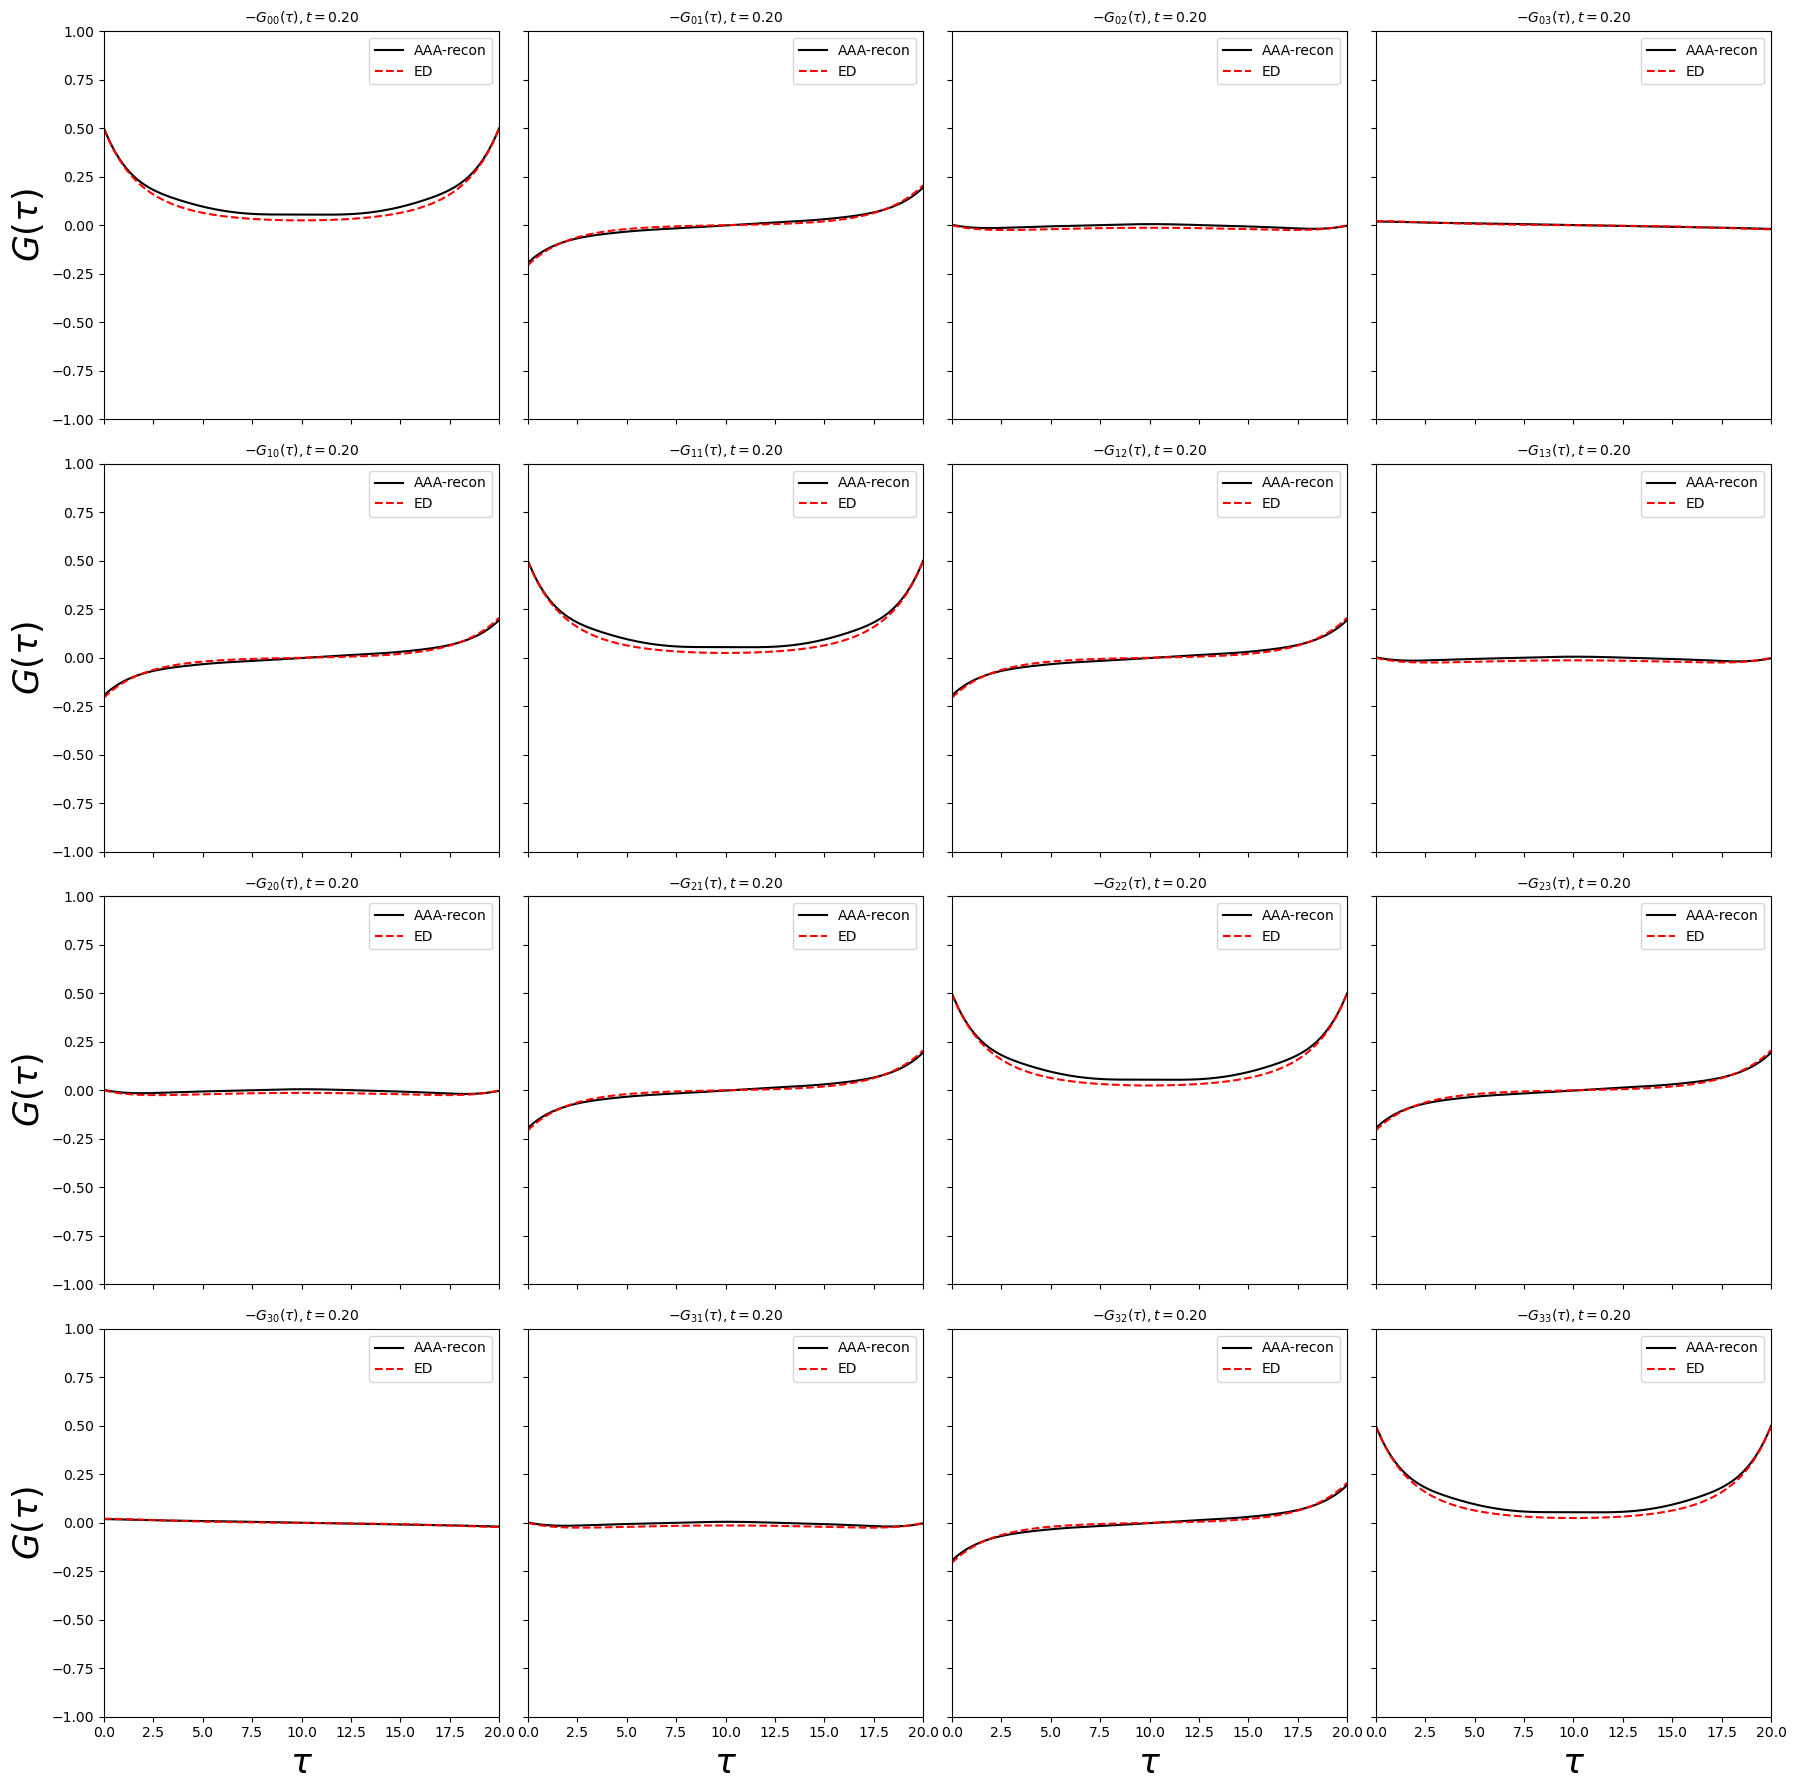

In [14]:
fig, axes = plt.subplots(Ns_plot, Ns_plot, figsize=(18, 18),sharex=True, sharey=True)

for i in range(Ns_plot):
    for j in range(Ns_plot):
        ax = axes[i, j]
        ax.plot(tau, -Gij_tau_interp[:, i ,j ].real, 'k', label= 'AAA-recon')
        ax.plot(tau, -Gij_tau_ED[id_ed, :, i ,j ].real, 'r--', label= 'ED')
        ax.set_title(r'$-G_{%d%d}(\tau), t=%.2f$'%(i,j, t_values_ED[id_ed]), fontsize=10)
        ax.tick_params(labelsize=10)
        ax.legend()
        if i == Ns_plot - 1:
            ax.set_xlabel(r"$\tau$", fontsize=25)
            ax.set_xlim([0, beta])
            ax.set_ylim([-1,1])
        if j == 0:
            ax.set_ylabel(r"$G(\tau)$", fontsize=25)

plt.tight_layout()
plt.show()

In [15]:
# threshold = 0.1
# mask = np.abs(wn) >= threshold
# deleted_idx = np.where(~mask)[0]

# wn_filter = wn[mask]
# Gij_iwn_interp_filter = Gij_iwn_interp_greedy[:, mask,:, :]

# fig, axes = plt.subplots(Ns_plot, Ns_plot, figsize=(18, 18),sharex=True, sharey=True)

# for i in range(Ns_plot):
#     for j in range(Ns_plot):
#         ax = axes[i, j]
#         if (-1)**(i+j) <0:
#             ax.plot(wn_filter, Gij_iwn_interp_filter[id_aaa, :, i ,j ].real, 'k', label= 'AAA-greedy')
#             ax.plot(wn, Gij_iwn_ED[id_ed, :, i ,j ].real, 'r--', label= 'ED')
#         else:
#             ax.plot(wn_filter, Gij_iwn_interp_filter[id_aaa, :, i ,j ].imag, 'k', label= 'AAA-greedy')
#             ax.plot(wn, Gij_iwn_ED[id_ed, :, i ,j ].imag, 'r--', label= 'ED')
#         ax.set_title(r'$G_{%d%d}(i\omega_n), t=%.2f$'%(i,j, t_values_ED[id_ed]), fontsize=25)
#         ax.tick_params(labelsize=25)
#         ax.legend()
#         if i == Ns_plot - 1:
#             ax.set_xlabel(r"$\omega_n$", fontsize=25)
#             ax.set_xlim([-20,20])
#             ax.set_ylim([-2,2])
#         if j == 0:
#             ax.set_ylabel(r"$G(i\omega_n)$", fontsize=25)

# plt.tight_layout()
# plt.show()


In [16]:
# tau = np.linspace(0,beta,401)
# d = dlr(lamb=beta*10.0, eps= 1e-10)
# print(Gij_iwn_interp_filter.shape)
# Gij_dlr = d.lstsq_dlr_from_matsubara(1j*wn_filter, Gij_iwn_interp_filter[id_aaa], beta)
# Gij_tau_interp = np.real(d.eval_dlr_tau(Gij_dlr, tau, beta))
# Gij_iwn_interp_recon = d.eval_dlr_freq(Gij_dlr, 1j*wn, beta)

In [ ]:
# fig, axes = plt.subplots(Ns_plot, Ns_plot, figsize=(18, 18),sharex=True, sharey=True)

# for i in range(Ns_plot):
#     for j in range(Ns_plot):
#         ax = axes[i, j]
#         if (-1)**(i+j) <0:
#             ax.plot(wn, Gij_iwn_interp_recon[:, i ,j ].real, 'k--', label= 'AAA-recon')
#             ax.plot(wn, Gij_iwn_ED[id_ed, :, i ,j ].real, 'r', label= 'ED')
#         else:
#             ax.plot(wn, Gij_iwn_interp_recon[:, i ,j ].imag, 'k--', label= 'AAA-recon')
#             ax.plot(wn, Gij_iwn_ED[id_ed, :, i ,j ].imag, 'r', label= 'ED')
#         ax.set_title(r'$G_{%d%d}(i\omega_n), t=%.2f$'%(i,j, t_values_ED[id_ed]), fontsize=10)
#         ax.tick_params(labelsize=10)
#         ax.legend()
#         if i == Ns_plot - 1:
#             ax.set_xlabel(r"$\omega_n$", fontsize=25)
#             ax.set_xlim([-20,20])
#             ax.set_ylim([-2,2])
#         if j == 0:
#             ax.set_ylabel(r"$G(i\omega_n)$", fontsize=25)

# plt.tight_layout()
# plt.show()

In [ ]:
# i= 0 
# j= 0 

# Gij_iwn_hf = np.zeros((len(t_values_ED), wn.size, Ns, Ns), dtype ='complex')
# Gij_iwn_hf_scaling = np.zeros((len(t_values_ED), wn.size, Ns, Ns), dtype ='complex')
# for t in range(t_values_ED.size):
#     Gij_iwn_hf[t], _ = wce.HF_G0(-t_values_ED[t], Ns, wn)
#     Gij_iwn_hf_scaling_temp, _ =  wce.HF_G0(1.0, Ns, wn/t_values_ED[t])
#     Gij_iwn_hf_scaling[t] = Gij_iwn_hf_scaling_temp/t_values_ED[t]
    
# plt.figure(0)
# plt.plot(wn, Gij_iwn_ED[-1,:, i,j].imag, 'C0', label = 'ED')
# plt.plot(wn, Gij_iwn_hf[-1,:, i,j].imag, 'C1--', label = 'HF')
# plt.plot(wn, Gij_iwn_hf_scaling[-1,:, i,j].imag, 'k', label = 'HF-scaling')
# plt.title(r'$t=%.2f$'%t_values_ED[-1])
# plt.xlim([-5,5])
# plt.ylim([-2,2])
# plt.legend()

In [ ]:
# i = 0
# j = 0
# n = Nw

# # Nt_end = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# plt.figure(0)
# plt.plot(t_values_wce, Gij_iwn_interp[:,n, i,j].imag, 'C0', label = 'original-AAA')
# plt.plot(t_values_wce, Gij_iwn_hf[:,n, i,j].imag, 'C2', label = 'HF')
# for Nt in range(25):
#     print("sce t_end is", sce_t[Nt-1])
#     t_app = np.concatenate([sce_t[: Nt] , wce_t ], axis=0)
#     G_app = np.concatenate([sce_G[: Nt] , wce_G ], axis=0)
#     r_AAA = AAA_adding0(t_app, 1j*G_app[:, n, i, j].imag,  rtol=err_bar1, max_terms= 40)
#     G_AAA = r_AAA(t_values_wce)
#     plt.plot(t_values_wce, G_AAA.imag, 'C1--')
    
# plt.plot(t_values_wce, G_AAA.imag, 'k--', linewidth =2, label = 'AAA')
# plt.xlim([0,2])
# plt.ylim([-2,2])
# plt.legend()

# i = 0
# j = 1
# plt.figure(1)
# plt.plot(t_values_wce, Gij_iwn_interp[:,n, i,j].real, 'C0', label = 'original-AAA')
# plt.plot(t_values_wce, Gij_iwn_hf[:,n, i,j].real, 'C2', label = 'HF')
# for Nt in range(25):
#     print("sce t_end is", sce_t[Nt-1])
#     t_app = np.concatenate([sce_t[: Nt] , wce_t ], axis=0)
#     G_app = np.concatenate([sce_G[: Nt] , wce_G ], axis=0)
#     r_AAA = AAA_adding0(t_app, G_app[:, n, i, j].real,  rtol=err_bar1, max_terms= 40)
#     G_AAA = r_AAA(t_values_wce)
#     plt.plot(t_values_wce, G_AAA.real, 'C1--')
    
# plt.plot(t_values_wce, G_AAA.real, 'k--', linewidth =2, label = 'AAA')
# plt.xlim([0,2])
# plt.ylim([-2,2])
# plt.legend()

# # print(sce_t.size)
# # print(wce_t.size)



In [ ]:
# def compare_l1(R):
#     N = R.shape[0]
    
#     # Pairwise L1 distances: shape (N, N)
#     D = np.abs(R[:, None, :] - R[None, :, :]).sum(axis=2)
    
#     # Ignore diagonal (distance to itself)
#     np.fill_diagonal(D, np.inf)
#     # Find argmin over all pairs
#     i_min, j_min = np.unravel_index(np.argmin(D), D.shape)

#     return i_min, j_min, D[i_min, j_min]

# def G_interp(G_sce, t_sce, G_wce, t_wce, t_eva, N_part= 5, err = 1e-3, max_terms= 40):
#     """ 
#     G_wce : Nt_wce *1 

#     """
#     Nt_wce = t_wce.size
#     Nt_sce = t_sce.size
#     Nt_tot = t_eva.size 

#     r_candidate = np.zeros((N_part+1, t_eva.size), dtype = complex)
#     N_gap = t_sce.size // N_part
    
#     ## Initial interpolation
#     t_app = np.concatenate([t_sce[:1], t_wce], axis=0)
#     G_app = np.concatenate([G_sce[:1], G_wce], axis=0)
    
#     r = AAA_adding0(t_app, G_app,  rtol=err, max_terms= max_terms)
#     r_candidate_supp = [r.support_points] 
#     r_candidate[0,:] = r(t_eva)  

    
#     k = 0 
#     for n in range(0, t_sce.size, N_gap):
#         print("n is", n)
#         t_app = np.concatenate([t_sce[:n+1], t_wce], axis=0)
#         G_app = np.concatenate([G_sce[:n+1], G_wce], axis=0)
        
#         r = AAA_adding0(t_app, G_app,  rtol=err, max_terms= max_terms)

#         ### Check whether the interpolation uses the same support points
#         exists = False
#         for v in r_candidate_supp:
#             if np.array_equal(r.support_points, v):
#                 print("The ",n, "-th candidate is the same, skip")
#                 exists = True
#                 break
                        
#         ### Check whether the interpolation is real-pole free
#         if not exists and np.min(np.abs(np.imag(r.poles()))) > 5*1e-2:
#             print("The ", n, "-th candidate is different and does not have real poles, keep")
#             k = k + 1
#             r_candidate_supp.append(r.support_points)
#             r_candidate[k,:] = r(t_eva) 
           
#     r_candidate = r_candidate[:k+1, :]   ## Cut the empty ones 
#     print("Total candidate interpolation is", r_candidate.shape[0])
#     if k == 0:
#         best_interp = r_candidate[0, :]
#         print('Return baseline')
#     else:
#         i_min, j_min,  diff = compare_l1(r_candidate)
#         best_interp = r_candidate[max(i_min,j_min), :]
#         print('Found Interpolation better than the baseline')
#         # if diff<1e-2:
#         #     best_interp = r_candidate[max(i_min,j_min), :]
#         #     print('Found Interpolation better than the baseline')
#         # else: 
#         #     best_interp = r_candidate[0, :]
#         #     print('Return baseline')
#     return best_interp

# def has_sign_change(v):
#     v = np.asarray(v)
#     return np.any(v > 0) and np.any(v < 0)
    
# def G_interp_v2(G_sce, t_sce, G_wce, t_wce, t_eva, err = 1e-3, max_terms= 40):
#     """ 
#     G_wce : Nt_wce *1 

#     """
    
#     ## Initial interpolation
#     for n in range(t_sce.size):
#         t_app = np.concatenate([t_sce[:n+1], t_wce], axis=0)
#         G_app = np.concatenate([G_sce[:n+1], G_wce], axis=0)
#         r = AAA_adding0(t_app, G_app,  rtol=err, max_terms= max_terms)
#         candidate_interp =  r(t_eva) 
#         sign_change = has_sign_change(candidate_interp)
#         print("Sign change", sign_change)
#         # if not sign_change and np.min(np.abs(np.imag(r.poles()))) > 5*1e-2:
#         if np.min(np.abs(np.imag(r.poles()))) > 5*1e-2:
#             best_interp = r(t_eva)
#             print("The ", n, "-th candidate does not have real poles, return it")
#             break
#     return best_interp
            

In [ ]:
# i = 0
# j = 0
# n = Nw
# G_greedy  = G_interp(sce_G[:, n, i, j].imag, sce_t, wce_G[:, n, i, j].imag, wce_t, t_values_wce, N_part=5)
# G_greedy2  = G_interp_v2(sce_G[:, n, i, j].imag, sce_t, wce_G[:, n, i, j].imag, wce_t, t_values_wce)
# plt.figure(1)
# plt.plot(t_values_wce, Gij_iwn_interp[:,n, i,j].imag, label = 'original-AAA')
# plt.plot(t_values_wce, Gij_iwn_hf[:,n, i, j].imag, label = 'HF')
# plt.plot(t_values_wce, G_greedy, '--', label = 'greedy')
# plt.plot(t_values_wce, G_greedy2, ':', label = 'greedy2')
# plt.xlim([0,2])
# # plt.ylim([-2,2])
# plt.legend()


# i = 0
# j = 1
# G_greedy  = G_interp(sce_G[:, n, i, j].real, sce_t, wce_G[:, n, i, j].real, wce_t, t_values_wce, N_part= 5)
# G_greedy2  = G_interp_v2(sce_G[:, n, i, j].real, sce_t, wce_G[:, n, i, j].real, wce_t, t_values_wce)

# plt.figure(2)
# plt.plot(t_values_wce, Gij_iwn_interp[:,n, i,j].real, label = 'original-AAA')
# plt.plot(t_values_wce, Gij_iwn_hf[:,n, i, j].real, label = 'HF')
# plt.plot(t_values_wce, G_greedy, '--', label = 'greedy')
# plt.plot(t_values_wce, G_greedy2, '--', label = 'greedy2')
# plt.xlim([0,2])
# plt.ylim([-2,2])
# plt.legend()
